## Import Libraries

In [ ]:
# !pip install itk --quiet
# !pip install itkwidgets --quiet
# !pip install ipywidgets --quiet

In [ ]:
# import itk
# import itkwidgets
import cv2
import imageio
from tensorflow.keras.utils import to_categorical
from ipywidgets import interact, interactive, IntSlider, ToggleButtons
from IPython.display import clear_output, Image
import tensorflow as tf
from tensorflow import keras
import json
import os
import pickle
import scipy.ndimage
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from tqdm import tqdm

In [ ]:
!pip list > dependencies.txt

In [ ]:
import tensorflow as tf
print(f'Versi TensorFlow: {tf.__version__}')

Versi TensorFlow: 2.19.0


## Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR = '/content/drive/MyDrive/Kelly/100p_brats2023'

## Data Exploration

#### Data

In [ ]:
img1_path = BASE_DIR + '/nnUNet_raw/nnUNet_raw_data/Task001_BraTS2023/imagesTr/K23_1250_0002.nii.gz'
img_obj = nib.load(img1_path)
print(f'Tipe data image: {type(img_obj)}')

Tipe data image: <class 'nibabel.nifti1.Nifti1Image'>


In [ ]:
img_data = img_obj.get_fdata()
type(img_data)
height, width, depth = img_data.shape
print(f'Shape gambar: height: {height}, width: {width}, depth: {depth}')
print(f'Dimensi data: {np.ndim(img_data)}')

Shape gambar: height: 240, width: 240, depth: 155
Dimensi data: 3


#### Visualisasi Data

Menampilkan slice gambar 69 dengan saluran: 2


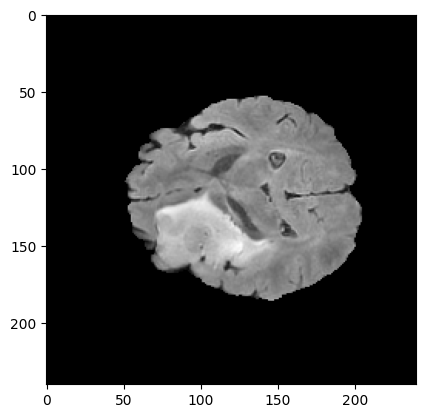

In [ ]:
vol_depth = 154
i = np.random.randint(0,vol_depth)
channel = 2

print(f'Menampilkan slice gambar {i} dengan saluran: {channel}')
plt.imshow(img_data[:,:,i], cmap='gray')
# plt.axis('off')

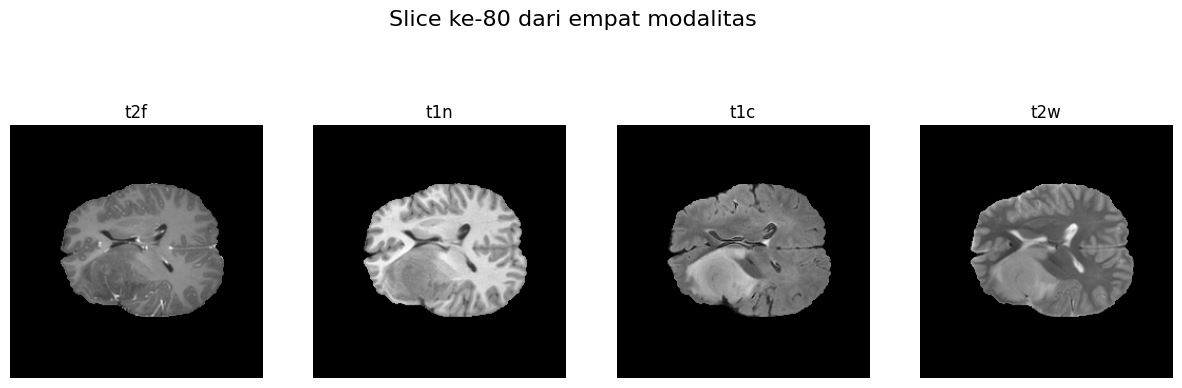

In [ ]:
BASE_CASE = '/content/drive/MyDrive/Kelly/100p_brats2023/nnUNet_raw/nnUNet_raw_data/Task001_BraTS2023/imagesTr/K23_1250'

i = 80

modalities = {
    "t2f":   BASE_CASE + "_0000.nii.gz",
    "t1n":     BASE_CASE + "_0001.nii.gz",
    "t1c":   BASE_CASE + "_0002.nii.gz",
    "t2w":     BASE_CASE + "_0003.nii.gz"
}

imgs = {name: nib.load(path).get_fdata() for name, path in modalities.items()}

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, (name, data) in zip(axes, imgs.items()):
    ax.imshow(data[:, :, i], cmap='gray')
    ax.set_title(name)
    ax.axis('off')

plt.suptitle(f'Slice ke-{i} dari empat modalitas', fontsize=16)
plt.show()

#### Interactive Visualisasi Data

In [ ]:
BASE_CASE = '/content/drive/MyDrive/Kelly/100p_brats2023/nnUNet_raw/nnUNet_raw_data/Task001_BraTS2023/imagesTr/K23_1250'
modalities = [
    ("t2f", BASE_CASE + "_0000.nii.gz"),
    ("t1n",   BASE_CASE + "_0001.nii.gz"),
    ("t1c",  BASE_CASE + "_0002.nii.gz"),
    ("t2w",   BASE_CASE + "_0003.nii.gz"),
]

vols = []
labels = []
for label, path in modalities:
    img = nib.load(path).get_fdata()
    vols.append(img)
    labels.append(label)

vol4d = np.stack(vols, axis=-1)

def img3d_explore(layer, channel=0):
    clear_output(wait=True)
    plt.figure(figsize=(6,6))
    plt.imshow(vol4d[:, :, layer, channel], cmap='gray')
    plt.title(f'Modality {channel} | Slice {layer}', fontsize=14)
    plt.axis('off')
    plt.show()
    return layer

interact(
    img3d_explore,
    layer=(0, vol4d.shape[2]-1),
    channel=(0, vol4d.shape[3]-1)
)

interactive(children=(IntSlider(value=77, description='layer', max=154), IntSlider(value=0, description='chann…

<function __main__.img3d_explore(layer, channel=0)>

#### Label

In [ ]:
label1_path = BASE_DIR + '/nnUNet_raw/nnUNet_raw_data/Task001_BraTS2023/labelsTr/K23_1249.nii.gz'
label_obj = nib.load(label1_path)
type(label_obj)

nibabel.nifti1.Nifti1Image

In [ ]:
label_data = label_obj.get_fdata()
type(label_data)
height, width, depth = label_data.shape
print(f'Shape label: height: {height}, width: {width}, depth: {depth}')

Shape label: height: 240, width: 240, depth: 155


In [ ]:
print(f'Nilai Unik pada label: {np.unique(label_data)}')

Nilai Unik pada label: [0. 1. 2. 3.]


In [ ]:
print(np.where(label_data == 2))

(array([ 54,  54,  54, ..., 118, 118, 118]), array([146, 146, 147, ..., 138, 138, 138]), array([60, 61, 60, ..., 84, 85, 86]))


#### Visualisasi Label

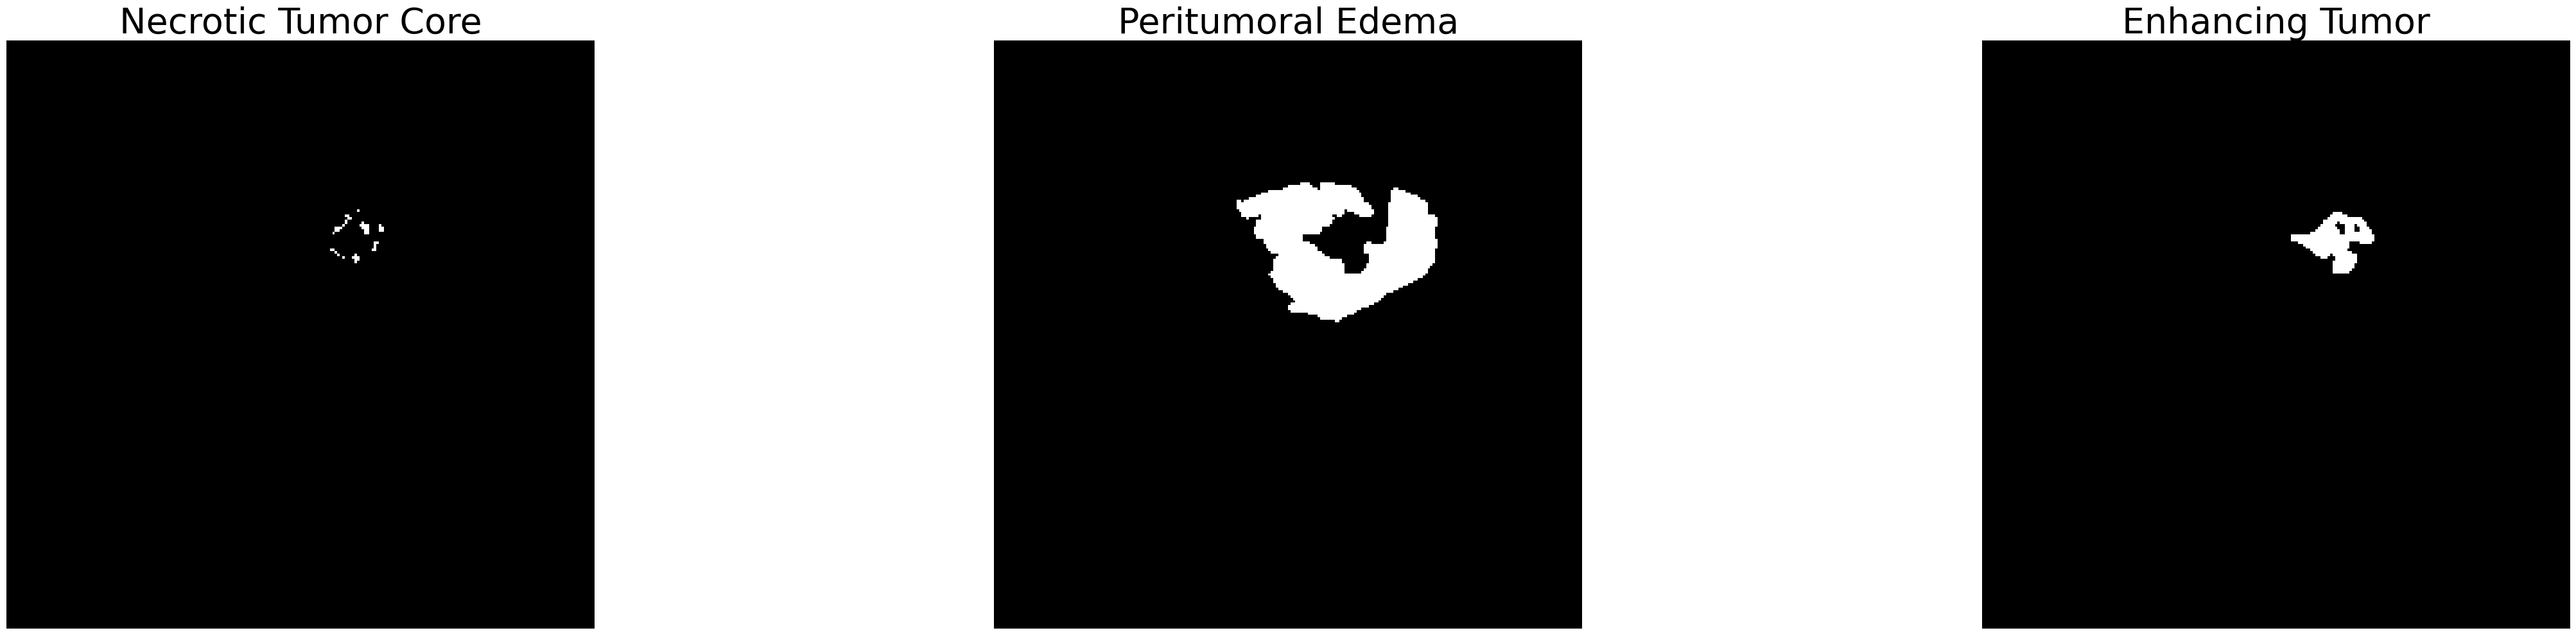

In [ ]:
layer = 80
class_dict = {
    'Necrotic Tumor Core': 1.,
    'Peritumoral Edema': 2.,
    'Enhancing Tumor': 3.
}

fig, ax = plt.subplots(nrows=1, ncols = 3, figsize=(50,10))
for i in range (3):
  img_label = list(class_dict.keys())[i]
  img = label_data[:,:,layer]
  mask = np.where(img==class_dict[img_label], 255,0)
  ax[i].imshow(mask, cmap='gray')
  ax[i].set_title(f'{img_label}', fontsize = 40)
  ax[i].axis('off')

plt.tight_layout()

#### Interactive Visualisasi Label

In [ ]:
select_class = ToggleButtons(
    options=['Necrotic Tumor Core', 'Peritumoral Edema', 'Enhancing Tumor'],
    description='Pilih Class:',
    disabled=False,
    button_style='info'
)
select_layer = IntSlider(min=0, max=154, description='Pilih Layer', continuous_update=False)

def plot_image(seg_class, layer):
    clear_output(wait=True)
    print(f'Menampilkan layer {layer} | Label: {seg_class}')
    img_label = class_dict[seg_class]
    mask = np.where(label_data[:, :, layer] == img_label, 255, 0)
    plt.figure(figsize=(10,5))
    plt.imshow(mask, cmap='gray')
    plt.axis('off')
    plt.show()

interactive(plot_image, seg_class=select_class, layer=select_layer)

interactive(children=(ToggleButtons(button_style='info', description='Pilih Class:', options=('Necrotic Tumor …

#### Visualisasi 3D

In [ ]:
# import numpy as np
# import nibabel as nib
# from mayavi import mlab

# # Run in pycharm
# BASE_CASE = "/content/drive/MyDrive/Kelly/100p_brats2023/nnUNet_raw/nnUNet_raw_data/Task001_BraTS2023/imagesTr/K23_1250"
# image_flair = nib.load(BASE_CASE + "_0000.nii.gz").get_fdata()
# label = nib.load("/content/drive/MyDrive/Kelly/100p_brats2023/nnUNet_raw/nnUNet_raw_data/Task001_BraTS2023/labelsTr/K23_1250.nii.gz").get_fdata()

# if image_flair.ndim == 4:
#     image_flair = image_flair[..., 0]

# mlab.figure(bgcolor=(0, 0, 0), size=(800, 600))

# src_image = mlab.pipeline.volume(
#     mlab.pipeline.scalar_field(image_flair),
#     color=(1, 1, 1)
# )

# color_map = {
#     1: (1, 0, 0),  # NCR = red
#     2: (0, 1, 0),  # ED = green
#     3: (0, 0, 1)   # ET = blue
# }

# for label_class, color in color_map.items():
#     labeled_volume = np.where(label == label_class, 1, 0)
#     src = mlab.pipeline.volume(
#         mlab.pipeline.scalar_field(labeled_volume),
#         color=color
#     )

# mlab.show()


## Data Preprocessing

##### Voxel dan Standarisasi

In [ ]:
import glob
import os

BASE_PATH = "/content/drive/MyDrive/Kelly/100p_brats2023/nnUNet_raw/nnUNet_raw_data/Task001_BraTS2023"
label_files = sorted(glob.glob(os.path.join(BASE_DIR, "labelsTr", "*.nii.gz")))


label_files = sorted(
    glob.glob(os.path.join(BASE_PATH, "labelsTr", "*.nii.gz"))
)
print("Found label files:", len(label_files))

if label_files:
    lbl_file = label_files[0]
    print("Example label file:", lbl_file)

    label = nib.load(lbl_file).get_fdata()
    print("Shape:", label.shape)

total_voxels = np.prod(label.shape)
tumor_voxels = np.sum(label > 0)
print("Tumor ratio:", tumor_voxels / total_voxels)

Found label files: 1251
Example label file: /content/drive/MyDrive/Kelly/100p_brats2023/nnUNet_raw/nnUNet_raw_data/Task001_BraTS2023/labelsTr/K23_0000.nii.gz
Shape: (240, 240, 155)
Tumor ratio: 0.006418570788530466


In [ ]:
def standarisasi(image):
  standarisasi_image = np.zeros(image.shape)
  for c in range(image.shape[0]):
    for z in range(image.shape[3]):
      image_slice = image[c,:,:,z]
      centered = image_slice - np.mean(image_slice)
      centered_scaled = centered / np.std(centered)
      standarisasi_image[c,:,:,z] = centered_scaled
  return standarisasi_image

def get_sub_volume(image, label,
                   orig_x = 240, orig_y = 240, orig_z = 155,
                   output_x = 160, output_y = 160, output_z = 16,
                   num_classes = 4, max_tries = 100,
                   background_threshold=0.995):
  X = None
  y = None
  start_x = None
  start_y = None
  start_z = None

  tries = 0
  while tries < max_tries:
    start_x = np.random.randint(0 , orig_x - output_x + 1)
    start_y = np.random.randint(0 , orig_y - output_y + 1)
    start_z = np.random.randint(0 , orig_z - output_z + 1)

    y = label[start_x: start_x + output_x,
              start_y: start_y + output_y,
              start_z: start_z + output_z]

    y = to_categorical(y, num_classes = num_classes)

    bgrd_ratio = np.sum(y[:,:,:,0]) / (output_x * output_y * output_z)

    tries += 1

    if bgrd_ratio < background_threshold:

        X = np.copy(image[start_x: start_x + output_x,
                          start_y: start_y + output_y,
                          start_z: start_z + output_z, :])

        X = np.moveaxis(X,3,0)
        X = standarisasi(X)
        y = np.moveaxis(y,3,0)
        y = y[1:, :, :, :]

        return X, y, start_x, start_y, start_z

    print(f"Percobaan ke-{tries} untuk menemukan sub-volume")

Crop preprocessed segmentation

In [ ]:
# from tqdm import tqdm
# import os, pickle, numpy as np, nibabel as nib, scipy.ndimage

# PP_stage = "/content/drive/MyDrive/Kelly/100p_brats2023/nnUNet_preprocessed/Task001_BraTS2023/nnUNetData_plans_v2.1_trgSp_1x1x1_stage0"
# PP_gt    = "/content/drive/MyDrive/Kelly/100p_brats2023/nnUNet_preprocessed/Task001_BraTS2023/gt_segmentations"
# OUT_DIR  = "/content/drive/MyDrive/Kelly/RSUU2Net/sub_volumes"
# os.makedirs(OUT_DIR, exist_ok=True)

# pkl_files = sorted([f for f in os.listdir(PP_stage) if f.endswith(".pkl")])

# for pkl_file in tqdm(pkl_files, desc="Rebuilding seg masks (canonical → crop → resample)"):
#     case_id  = pkl_file[:-4]
#     pkl_path = os.path.join(PP_stage, pkl_file)
#     seg_path = os.path.join(PP_gt, f"{case_id}.nii.gz")

#     with open(pkl_path, "rb") as f:
#         meta = pickle.load(f)
#     (x1,x2), (y1,y2), (z1,z2) = meta["crop_bbox"]
#     target_shape = tuple(meta["size_after_resampling"])

#     seg_ras = nib.as_closest_canonical(nib.load(seg_path)).get_fdata().astype(np.uint8)

#     seg_crop = seg_ras[x1:x2, y1:y2, z1:z2]

#     zoom = np.array(target_shape) / np.array(seg_crop.shape)
#     seg_resampled = scipy.ndimage.zoom(seg_crop, zoom=zoom, order=0)

#     np.save(os.path.join(OUT_DIR, f"{case_id}_seg.npy"), seg_resampled)

# print(f"Done. Saved to {OUT_DIR}")


In [ ]:
# import numpy as np, matplotlib.pyplot as plt

# case_id   = "K23_1239"
# stage_dir = "/content/drive/MyDrive/Kelly/100p_brats2023/nnUNet_preprocessed/Task001_BraTS2023/nnUNetData_plans_v2.1_trgSp_1x1x1_stage0"
# seg_dir   = "/content/drive/MyDrive/Kelly/RSUU2Net/sub_volumes"

# image = np.load(f"{stage_dir}/{case_id}.npz")["data"]         # (C, X, Y, Z)
# seg   = np.load(f"{seg_dir}/{case_id}_seg.npy")               # (X, Y, Z)

# print("Image shape:", image.shape)
# print("Seg shape:",   seg.shape)

# modality = 0                       # pick the channel you want to view
# z = seg.shape[-1] // 2             # middle slice
# mri = image[modality, :, :, z]
# mask = seg[:, :, z]

# plt.figure(figsize=(6,6))
# plt.imshow(mri, cmap="gray")
# plt.imshow(np.ma.masked_where(mask == 0, mask), cmap="jet", alpha=0.5)
# plt.title(f"Case {case_id} | Modality {modality} | Slice {z}")
# plt.axis("off")
# plt.show()


##### Menyimpan Voxel

In [ ]:
# import os
# import glob
# import nibabel as nib
# import numpy as np
# import h5py
# import json


# def stack_modalities(case_id, base_dir):
#     """Stack 4 modality files (0000–0003) into one 4D array (H,W,D,4)."""
#     files = [
#         f"{base_dir}/imagesTr/{case_id}_0000.nii.gz",
#         f"{base_dir}/imagesTr/{case_id}_0001.nii.gz",
#         f"{base_dir}/imagesTr/{case_id}_0002.nii.gz",
#         f"{base_dir}/imagesTr/{case_id}_0003.nii.gz"
#     ]
#     vols = [nib.load(f).get_fdata() for f in files]
#     return np.stack(vols, axis=-1)


# def load_data(img_file, lbl_file):
#     if isinstance(img_file, str):
#         image = np.array(nib.load(img_file).get_fdata())
#     else:
#         image = img_file
#     label = np.array(nib.load(lbl_file).get_fdata())
#     return image, label


# def save_sub_volumes_all_images(num_sub_volumes, output_dir, case_id, base_dir, lbl_file, max_attempts=50):
#     if not os.path.exists(output_dir):
#         os.makedirs(output_dir)

#     image = stack_modalities(case_id, base_dir)
#     label = np.array(nib.load(lbl_file).get_fdata())

#     sub_volume_generated = False
#     attempts = 0

#     for i in range(1, num_sub_volumes+1):
#         sub_vol = get_sub_volume(image, label)

#         while (sub_vol is not None and np.isnan(sub_vol[0]).any()) and attempts < max_attempts:
#             print(f"Sub-volume {i} for {case_id} Terdapat nan value. Generate yang baru.")
#             sub_vol = get_sub_volume(image, label)
#             attempts += 1

#         if attempts == max_attempts or sub_vol is None:
#             print(f"Gagal mendapatkan sub-volume tanpa NaN setelah {max_attempts} atau sub volume adalah None. Melanjutkan ke gambar berikutnya.")
#             break

#         X, y, start_x, start_y, start_z = sub_vol
#         h5_file = os.path.join(
#             output_dir,
#             f"{case_id}_{i}_x{start_x}_y{start_y}_z{start_z}.h5"
#         )
#         with h5py.File(h5_file, 'w') as hf:
#             hf.create_dataset('x', data=X, compression='gzip', compression_opts=9)
#             hf.create_dataset('y', data=y, compression='gzip', compression_opts=9)

#         sub_volume_generated = True

#     if not sub_volume_generated:
#         print(f"Tidak ada sub-volume yang memenuhi kriteria untuk {case_id}")


# BASE_DIR = "/content/drive/MyDrive/Kelly/100p_brats2023/nnUNet_raw/nnUNet_raw_data/Task001_BraTS2023"
# OUTPUT_DIR = "/content/drive/MyDrive/Kelly/RSUU2Net/sub_volume"

# label_files = sorted(glob.glob(os.path.join(BASE_DIR, "labelsTr", "*.nii.gz")))
# cases = [os.path.basename(f).replace(".nii.gz", "") for f in label_files]

# for case_id, lbl_file in zip(cases, label_files):
#     print(f"Processing {case_id} ...")
#     save_sub_volumes_all_images(5, OUTPUT_DIR, case_id, BASE_DIR, lbl_file)


Processing K23_0000 ...
Percobaan ke-1 untuk menemukan sub-volume
Percobaan ke-2 untuk menemukan sub-volume
Percobaan ke-3 untuk menemukan sub-volume
Percobaan ke-1 untuk menemukan sub-volume
Percobaan ke-2 untuk menemukan sub-volume
Percobaan ke-3 untuk menemukan sub-volume
Percobaan ke-1 untuk menemukan sub-volume
Percobaan ke-2 untuk menemukan sub-volume
Percobaan ke-3 untuk menemukan sub-volume
Percobaan ke-4 untuk menemukan sub-volume
Percobaan ke-5 untuk menemukan sub-volume
Percobaan ke-6 untuk menemukan sub-volume
Percobaan ke-1 untuk menemukan sub-volume
Percobaan ke-2 untuk menemukan sub-volume
Percobaan ke-3 untuk menemukan sub-volume
Percobaan ke-4 untuk menemukan sub-volume
Percobaan ke-5 untuk menemukan sub-volume
Processing K23_0001 ...
Percobaan ke-1 untuk menemukan sub-volume
Percobaan ke-2 untuk menemukan sub-volume
Processing K23_0002 ...


/tmp/ipython-input-3184774874.py:7: RuntimeWarning: invalid value encountered in divide
  centered_scaled = centered / np.std(centered)


Sub-volume 1 for K23_0002 Terdapat nan value. Generate yang baru.
Percobaan ke-1 untuk menemukan sub-volume
Sub-volume 5 for K23_0002 Terdapat nan value. Generate yang baru.
Percobaan ke-1 untuk menemukan sub-volume
Processing K23_0003 ...
Percobaan ke-1 untuk menemukan sub-volume
Percobaan ke-1 untuk menemukan sub-volume
Percobaan ke-1 untuk menemukan sub-volume
Percobaan ke-2 untuk menemukan sub-volume
Processing K23_0004 ...
Percobaan ke-1 untuk menemukan sub-volume
Percobaan ke-2 untuk menemukan sub-volume
Percobaan ke-1 untuk menemukan sub-volume
Percobaan ke-1 untuk menemukan sub-volume
Percobaan ke-2 untuk menemukan sub-volume
Percobaan ke-3 untuk menemukan sub-volume
Percobaan ke-4 untuk menemukan sub-volume
Processing K23_0005 ...
Percobaan ke-1 untuk menemukan sub-volume
Percobaan ke-1 untuk menemukan sub-volume
Percobaan ke-2 untuk menemukan sub-volume
Percobaan ke-1 untuk menemukan sub-volume
Percobaan ke-2 untuk menemukan sub-volume
Percobaan ke-3 untuk menemukan sub-volum

(4, 160, 160, 16)
(3, 160, 160, 16)


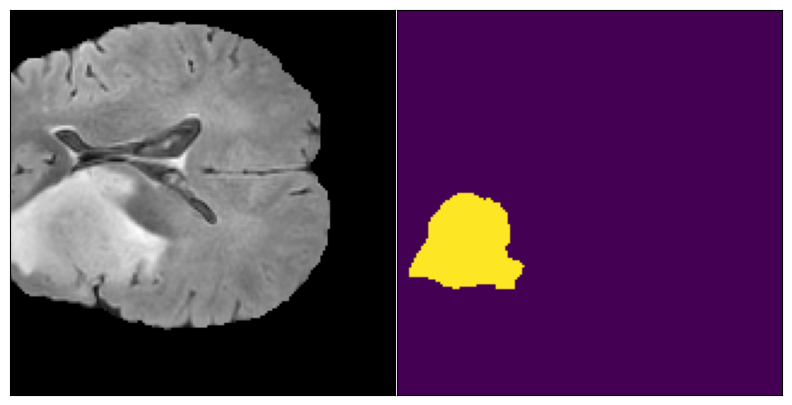

In [ ]:
import h5py
def visualize_patch(X, y):
    fig, ax = plt.subplots(1, 2, figsize=[10, 5], squeeze=False)

    ax[0][0].imshow(X[:, :, 0], cmap='gray')
    ax[0][0].set_yticks([])
    ax[0][0].set_xticks([])
    ax[0][1].imshow(y[:, :, 0], cmap='viridis')
    ax[0][1].set_xticks([])
    ax[0][1].set_yticks([])

    fig.subplots_adjust(wspace=0, hspace=0)

file_name = '/content/drive/MyDrive/Kelly/RSUU2Net/sub_volume/K23_1250_5_x50_y68_z84.h5'

with h5py.File(file_name, 'r') as hf:
    image_data = hf['x'][:]
    label_data = hf['y'][:]
print(image_data.shape)
print(label_data.shape)
visualize_patch(image_data[2], label_data[0])

plt.show()

In [ ]:
# import os
# import shutil
# import random
# import json

# all_dir = '/content/drive/MyDrive/Kelly/RSUU2Net/sub_volume'
# temp_dir = '/content/RSUU2Net_splits'
# train_dir = os.path.join(temp_dir, 'training')
# val_dir   = os.path.join(temp_dir, 'validation')
# test_dir  = os.path.join(temp_dir, 'testing')

# for d in [train_dir, val_dir, test_dir]:
#     os.makedirs(d, exist_ok=True)

# all_h5_files = [f for f in os.listdir(all_dir) if f.endswith('.h5')]

# def get_case_id(filename):
#     return "_".join(filename.split("_")[:2])

# case_ids = sorted(set(get_case_id(f) for f in all_h5_files))

# random.seed(42)
# random.shuffle(case_ids)

# n_total = len(case_ids)
# n_train = int(0.7 * n_total)
# n_val   = int(0.15 * n_total)
# n_test  = n_total - n_train - n_val

# train_cases = case_ids[:n_train]
# val_cases   = case_ids[n_train:n_train+n_val]
# test_cases  = case_ids[n_train+n_val:]

# train_files, val_files, test_files = [], [], []

# for f in all_h5_files:
#     case_id = get_case_id(f)
#     src = os.path.join(all_dir, f)
#     if case_id in train_cases:
#         shutil.copy(src, os.path.join(train_dir, f))
#         train_files.append(f)
#     elif case_id in val_cases:
#         shutil.copy(src, os.path.join(val_dir, f))
#         val_files.append(f)
#     else:
#         shutil.copy(src, os.path.join(test_dir, f))
#         test_files.append(f)

# final_data = {
#     "training": sorted(train_files),
#     "validation": sorted(val_files),
#     "testing": sorted(test_files)
# }

# config_path = os.path.join(temp_dir, "configurasi.json")
# with open(config_path, 'w') as json_file:
#     json.dump(final_data, json_file, indent=4)

# print(f"Split {n_total} cases into {n_train} train, {n_val} val, {n_test} test.")
# print("Saved locally at:", temp_dir)

# drive_target = "/content/drive/MyDrive/Kelly/RSUU2Net"
# shutil.copytree(temp_dir, drive_target, dirs_exist_ok=True)
# print(f"Copied results back to Drive: {drive_target}")

Split 1251 cases into 875 train, 187 val, 189 test.
Saved locally at: /content/RSUU2Net_splits
Copied results back to Drive: /content/drive/MyDrive/Kelly/RSUU2Net


In [ ]:
import os
import json

direktori_train = '/content/drive/MyDrive/Kelly/RSUU2Net/training'
direktori_val = '/content/drive/MyDrive/Kelly/RSUU2Net/validation'
direktori_test = '/content/drive/MyDrive/Kelly/RSUU2Net/testing'

def collect_h5_files(directory):
    h5_files = [file for file in os.listdir(directory) if file.endswith(".h5")]
    return sorted(h5_files)

train_h5_files = collect_h5_files(direktori_train)
val_h5_files = collect_h5_files(direktori_val)
test_h5_files = collect_h5_files(direktori_test)

final_data = {"training": train_h5_files, "validation": val_h5_files, "testing": test_h5_files}

with open('configurasi.json', 'w') as json_file:
    json.dump(final_data, json_file, indent=4)


Training cases		: 87
Validation cases	: 18
Testing cases		: 18
Total cases			: 123 



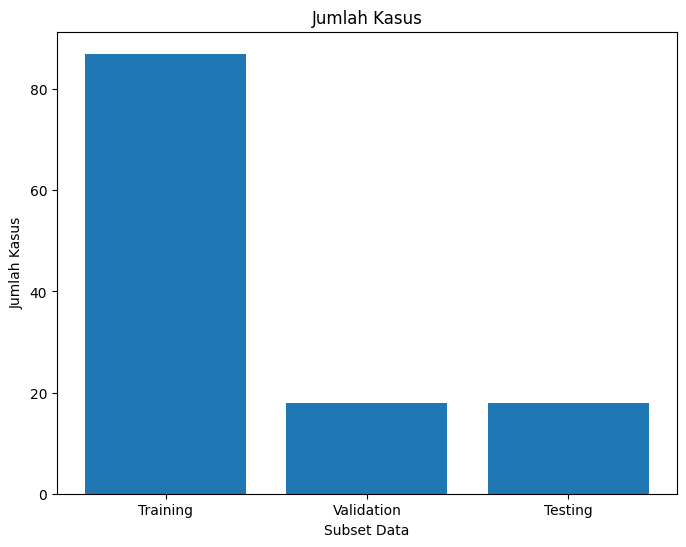

In [ ]:
import os
import matplotlib.pyplot as plt
import random

def get_case_id(filename):
    return "_".join(filename.split("_")[:2])

def get_unique_cases(directory):
    files = [f for f in os.listdir(directory) if f.endswith(".h5")]
    case_ids = list(set(get_case_id(f) for f in files))
    return case_ids

def sample_cases(case_ids, percentage=0.1):
    random.shuffle(case_ids)
    sample_size = int(len(case_ids) * percentage)
    return case_ids[:sample_size]

train_dir = '/content/drive/MyDrive/Kelly/RSUU2Net/training'
val_dir   = '/content/drive/MyDrive/Kelly/RSUU2Net/validation'
test_dir  = '/content/drive/MyDrive/Kelly/RSUU2Net/testing'

train_ids = get_unique_cases(train_dir)
val_ids   = get_unique_cases(val_dir)
test_ids  = get_unique_cases(test_dir)

# jumlah_data = [len(train_sample), len(val_sample), len(test_sample)]

# num_cases_train, train_ids = count_unique_cases(train_dir)
# num_cases_val, val_ids     = count_unique_cases(val_dir)
# num_cases_test, test_ids   = count_unique_cases(test_dir)

train_sample = sample_cases(train_ids, 0.1)
val_sample   = sample_cases(val_ids, 0.1)
test_sample  = sample_cases(test_ids, 0.1)
jumlah_data = [len(train_sample), len(val_sample), len(test_sample)]

print("Training cases\t\t:", len(train_sample))
print("Validation cases\t:", len(val_sample))
print("Testing cases\t\t:", len(test_sample))
print("==========================")
print("Total cases\t\t\t:", sum(jumlah_data), "\n")

labels = ['Training', 'Validation', 'Testing']

plt.figure(figsize=(8,6))
plt.bar(labels, jumlah_data)
plt.xlabel('Subset Data')
plt.ylabel('Jumlah Kasus')
plt.title('Jumlah Kasus')
plt.show()

Data training		: 87
Data validation		: 18
Data testing		: 18 



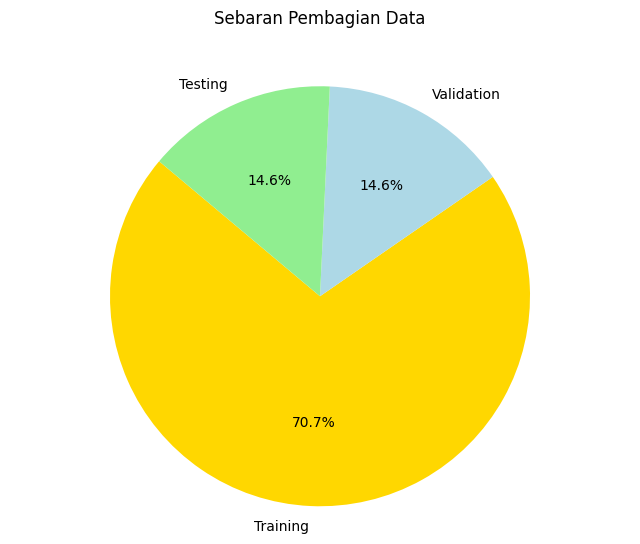

In [ ]:

print(f'Data training\t\t: {len(train_sample)}')
print(f'Data validation\t\t: {len(val_sample)}')
print(f'Data testing\t\t: {len(test_sample)} \n')

jumlah_data = [len(train_sample), len(val_sample), len(test_sample)]
# jumlah_data = [num_cases_train, num_cases_val, num_cases_test]
labels = ['Training', 'Validation', 'Testing']

# persentase_data = [num / sub_volume * 100 for num in jumlah_data]
total = sum(jumlah_data)
persentase_data = [(num / total) * 100 for num in jumlah_data]
# persentase_data = [num / sub_volume * 100 for num in jumlah_data]

plt.figure(figsize=(8, 6))
colors = ['gold', 'lightblue', 'lightgreen']
plt.pie(persentase_data, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Sebaran Pembagian Data', pad=30)
plt.axis('equal')
plt.show()

##### Generator

In [ ]:
# import h5py
# import numpy as np
# class VolumeDataGenerator(tf.keras.utils.Sequence):
#     def __init__(self,
#                  sample_list,
#                  base_dir,
#                  batch_size=1,
#                  shuffle=True,
#                  dim=(160, 160, 16),
#                  num_channels=4,
#                  num_classes=3,
#                  verbose=1,
#                  seed=42, **kwargs):
#         super().__init__(**kwargs)

#         self.batch_size = batch_size
#         self.shuffle = shuffle
#         self.base_dir = base_dir
#         self.dim = dim
#         self.num_channels = num_channels
#         self.num_classes = num_classes
#         self.verbose = verbose
#         self.seed = seed
#         self.sample_list = sample_list
#         self.on_epoch_end()

#     def on_epoch_end(self):
#         self.indexes = np.arange(len(self.sample_list))
#         if self.shuffle == True:
#             np.random.seed(self.seed)
#             np.random.shuffle(self.indexes)

#     def __len__(self):
#         return int(np.floor(len(self.sample_list) / self.batch_size))

#     def __data_generation(self, list_IDs_temp):
#         X = np.zeros((self.batch_size, self.num_channels, *self.dim),
#                      dtype=np.float32)
#         y = np.zeros((self.batch_size, self.num_classes, *self.dim),
#                      dtype=np.float32)

#         for i, ID in enumerate(list_IDs_temp):
#             if self.verbose == 1:
#                 print("Training on: %s" % self.base_dir + ID)
#             with h5py.File(self.base_dir + ID, 'r') as f:
#                 X[i] = np.array(f.get("x"))
#                 y[i] = np.array(f.get("y"))
#         return X, y

#     def __getitem__(self, index):
#         indexes = self.indexes[
#                   index * self.batch_size: (index + 1) * self.batch_size]
#         sample_list_temp = [self.sample_list[k] for k in indexes]
#         X, y = self.__data_generation(sample_list_temp)

#         return X, y

In [ ]:
def load_h5_file(path, num_channels=4, num_classes=3, dim=(160,160,16)):
    def _py_load(path_bytes):
        # Ensure we get a proper string path
        if isinstance(path_bytes, (np.ndarray, np.generic)):
            path_str = path_bytes.item().decode("utf-8") if isinstance(path_bytes.item(), (bytes, bytearray)) else str(path_bytes.item())
        elif isinstance(path_bytes, (bytes, bytearray)):
            path_str = path_bytes.decode("utf-8")
        else:
            path_str = str(path_bytes)

        with h5py.File(path_str, "r") as f:
            x = np.array(f["x"], dtype=np.float32)
            y = np.array(f["y"], dtype=np.float32)
        return x, y

    x, y = tf.numpy_function(
        _py_load, [path], [tf.float32, tf.float32]
    )
    x.set_shape((num_channels, *dim))
    y.set_shape((num_classes, *dim))
    return x, y


In [ ]:
# def build_dataset(file_list, base_dir, batch_size=2, shuffle=True):
#     paths = [os.path.join(base_dir, f) for f in file_list]
#     ds = tf.data.Dataset.from_tensor_slices(paths)

#     if shuffle:
#         ds = ds.shuffle(buffer_size=len(paths), reshuffle_each_iteration=True)

#     ds = ds.map(
#         lambda path: load_h5_file(path),
#         num_parallel_calls=tf.data.AUTOTUNE
#     )

#     ds = ds.batch(batch_size)
#     ds = ds.prefetch(tf.data.AUTOTUNE)
#     return ds

In [ ]:
# tes_dir = "/content/drive/MyDrive/Kelly/RSUU2Net"
# with open(tes_dir + "/configurasi.json") as json_file:
#     config = json.load(json_file)

# train_ds = build_dataset(config["training"], os.path.join(tes_dir, "training"), batch_size=2)
# val_ds   = build_dataset(config["validation"], os.path.join(tes_dir, "validation"), batch_size=2, shuffle=False)
# test_ds  = build_dataset(config["testing"], os.path.join(tes_dir, "testing"), batch_size=2, shuffle=False)

In [ ]:
# tes_dir = "/content/drive/MyDrive/Kelly/RSUU2Net"
# with open(tes_dir + "/configurasi.json") as json_file:
#   config = json.load(json_file)

In [ ]:
# train_generator = VolumeDataGenerator(config["training"], "/content/drive/MyDrive/Kelly/RSUU2Net/training/", batch_size=2, dim = (160,160,16), verbose=2)
# valid_generator = VolumeDataGenerator(config["validation"], "/content/drive/MyDrive/Kelly/RSUU2Net/validation/", batch_size=2, dim = (160,160,16), verbose=2)
# test_generator = VolumeDataGenerator(config["testing"], "/content/drive/MyDrive/Kelly/RSUU2Net/testing/", batch_size=2, dim = (160,160,16), verbose=2)

In [ ]:
def build_dataset(file_list, batch_size=2, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(file_list)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_list))

    ds = ds.map(
        lambda path: load_h5_file(path),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [ ]:
def filter_files_by_case(directory, selected_cases):
    files = os.listdir(directory)
    filtered = [
        os.path.join(directory, f)
        for f in files
        if f.endswith(".h5") and get_case_id(f) in selected_cases
    ]
    return filtered

In [ ]:
train_files = filter_files_by_case(train_dir, train_sample)
val_files   = filter_files_by_case(val_dir, val_sample)
test_files  = filter_files_by_case(test_dir, test_sample)

In [ ]:
tes_dir = "/content/drive/MyDrive/Kelly/RSUU2Net"
with open(tes_dir + "/configurasi.json") as json_file:
    config = json.load(json_file)

In [ ]:
train_ds = build_dataset(train_files, batch_size=2, shuffle=True)
val_ds   = build_dataset(val_files, batch_size=2, shuffle=False)
test_ds  = build_dataset(test_files, batch_size=2, shuffle=False)

In [ ]:
print("Train files:", len(train_files))
print("Val files:", len(val_files))

Train files: 635
Val files: 110


### Eksplorasi Preprocessed Data

## Desain Arsitektur dan Training Model

### Loss Function and Metrics

In [ ]:
# from tensorflow.keras import backend as K
# import numpy as np

# def soft_dice_loss(y_true, y_pred, axis=(1, 2, 3),
#                    epsilon=0.00001):
#     dice_numerator = 2 * K.sum(y_true * y_pred , axis= axis) + epsilon
#     dice_denominator = K.sum(y_true ** 2, axis= axis) + K.sum(y_pred ** 2 , axis = axis) + epsilon
#     dice_loss = 1 - K.mean(dice_numerator / dice_denominator)
#     return dice_loss

# # def focal_dice_loss(y_true, y_pred, gamma=2, alpha=0.5, axis=(1, 2, 3), epsilon=1e-5):
# #     dice_numerator = 2 * K.sum(y_true * y_pred, axis=axis) + epsilon
# #     dice_denominator = K.sum(y_true ** 2, axis=axis) + K.sum(y_pred ** 2, axis=axis) + epsilon
# #     dice_coefficient = dice_numerator / dice_denominator
# #     pt = (dice_numerator + epsilon) / (dice_denominator + epsilon)
# #     focal_loss = -alpha * (1 - pt)**gamma * K.log(pt)
# #     return K.mean(focal_loss + (1 - dice_coefficient))

# def dice_coefficient(y_true, y_pred, axis=(1, 2, 3), epsilon=0.00001):
#     dice_numerator = 2 * K.sum(y_true * y_pred , axis = axis) + epsilon
#     dice_denominator = K.sum(y_true, axis = axis ) + K.sum(y_pred, axis = axis) + epsilon
#     dice_coefficient = K.mean(dice_numerator/dice_denominator)
#     return dice_coefficient

# def mean_iou(y_true, y_pred, axis=(1, 2, 3), epsilon=0.00001):
#     intersection = K.sum(y_true * y_pred, axis=axis)
#     union = K.sum(y_true, axis=axis) + K.sum(y_pred, axis=axis) - intersection + epsilon
#     iou = (intersection + epsilon) / (union + epsilon)
#     iou_mean = K.mean(iou)
#     return iou_mean

KeyboardInterrupt: 

In [ ]:
from tensorflow.keras import backend as K

def soft_dice_loss(y_true, y_pred, epsilon=1e-5):
    # sum over spatial dims only
    axis = (2, 3, 4)

    numerator = 2.0 * K.sum(y_true * y_pred, axis=axis) + epsilon
    denominator = K.sum(y_true, axis=axis) + K.sum(y_pred, axis=axis) + epsilon

    dice_per_class = numerator / denominator
    return 1.0 - K.mean(dice_per_class)


def dice_coefficient(y_true, y_pred, epsilon=1e-5):
    axis = (2, 3, 4)

    numerator = 2.0 * K.sum(y_true * y_pred, axis=axis) + epsilon
    denominator = K.sum(y_true, axis=axis) + K.sum(y_pred, axis=axis) + epsilon

    dice_per_class = numerator / denominator
    return K.mean(dice_per_class)


def mean_iou(y_true, y_pred, epsilon=1e-5):
    axis = (2, 3, 4)

    intersection = K.sum(y_true * y_pred, axis=axis)
    union = K.sum(y_true + y_pred, axis=axis) - intersection + epsilon

    iou_per_class = (intersection + epsilon) / union
    return K.mean(iou_per_class)

### UNet Architecture

In [ ]:
from tensorflow.keras.layers import Input, Activation, Conv3D, Conv3DTranspose, MaxPooling3D, UpSampling3D, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
tf.keras.backend.set_image_data_format('channels_first')

def create_convolution_block(input_layer, n_filters, batch_normalization=False,
                             kernel=(3, 3, 3), activation=None,
                             padding='same', strides=(1, 1, 1),
                             instance_normalization=False):

    layer = Conv3D(n_filters, kernel, padding=padding, strides=strides)(input_layer)
    if activation is None:
        return Activation('relu')(layer)
    else:
        return activation()(layer)

def get_up_convolution(n_filters, pool_size, kernel_size=(2, 2, 2),
                       strides=(2, 2, 2),
                       deconvolution=False):
    if deconvolution:
        return Conv3DTranspose(filters=n_filters, kernel_size=kernel_size, strides=strides)
    else:
        return UpSampling3D(size=pool_size)

def unet_model_3d(loss_function, input_shape=(4, 160, 160, 16),
                  pool_size=(2, 2, 2), n_labels=3,
                  initial_learning_rate=0.00001,
                  deconvolution=False, depth=4, n_base_filters=32,
                  include_label_wise_dice_coefficients=False, metrics=[],
                  batch_normalization=False, activation_name="sigmoid"):

    inputs = Input(input_shape)
    current_layer = inputs
    levels = list()

    for layer_depth in range(depth):
        layer1 = create_convolution_block(input_layer=current_layer,
                                          n_filters=n_base_filters * (2 ** layer_depth),
                                          batch_normalization=batch_normalization)
        layer2 = create_convolution_block(input_layer=layer1,
                                          n_filters=n_base_filters * (2 ** layer_depth) * 2,
                                          batch_normalization=batch_normalization)
        if layer_depth < depth - 1:
            current_layer = MaxPooling3D(pool_size=pool_size)(layer2)
            levels.append([layer1, layer2, current_layer])
        else:
            current_layer = layer2
            levels.append([layer1, layer2])

    for layer_depth in range(depth - 2, -1, -1):
        up_convolution = get_up_convolution(pool_size=pool_size,
                                            deconvolution=deconvolution,
                                            n_filters=current_layer.shape[1])(
            current_layer)
        concat = concatenate([up_convolution, levels[layer_depth][1]], axis=1)
        current_layer = create_convolution_block(
            n_filters=levels[layer_depth][1].shape[1],
            input_layer=concat, batch_normalization=batch_normalization)
        current_layer = create_convolution_block(
            n_filters=levels[layer_depth][1].shape[1],
            input_layer=current_layer,
            batch_normalization=batch_normalization)

    final_convolution = Conv3D(n_labels, (1, 1, 1))(current_layer)
    act = Activation(activation_name)(final_convolution)
    model = Model(inputs=inputs, outputs=act)

    if not isinstance(metrics, list):
        metrics = [metrics]

    model.compile(optimizer=Adam(learning_rate=initial_learning_rate), loss=loss_function, metrics=metrics)
    return model

In [ ]:
model = unet_model_3d(loss_function=soft_dice_loss, metrics=[mean_iou, dice_coefficient])
model.summary()

In [ ]:
model.fit(train_generator,
        epochs=35,
        use_multiprocessing=True,
        validation_data=valid_generator
        )

In [ ]:
# model.save_weights('/content/drive/MyDrive/Projek_Skripsi_RSU_U^2_Net_3D/3DSegmentationRSU_U^2Net++/model/weight_model_U-Net.hdf5')
# model.load_weights('/content/drive/MyDrive/Projek_Skripsi_RSU_U^2_Net_3D/3DSegmentationRSU_U^2Net++/model/weight_model_U-Net.hdf5')

### CBAM RSU U^2 Net+ Architecture (Proposed Architecture)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv3D, BatchNormalization, Activation, MaxPooling3D, UpSampling3D, Concatenate, Add, GlobalAveragePooling3D, Dense, Reshape, Multiply, Lambda
tf.keras.backend.set_image_data_format('channels_first')

def conv_block(inputs, out_ch, rate=1):
    x = Conv3D(out_ch, 3, padding="same", dilation_rate=1)(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x

def ChannelAttention(x, reduction=16):
    channels = x.shape[1]
    avg_pool = GlobalAveragePooling3D(data_format="channels_first")(x)
    max_pool = Lambda(lambda z: tf.reduce_max(z, axis=[2, 3, 4]))(x)

    shared_dense_one = Dense(channels // reduction, activation="relu")
    shared_dense_two = Dense(channels)

    avg_out = shared_dense_two(shared_dense_one(avg_pool))
    max_out = shared_dense_two(shared_dense_one(max_pool))

    cbam_feature = Activation("sigmoid")(Add()([avg_out, max_out]))
    cbam_feature = Reshape((channels, 1, 1, 1))(cbam_feature)

    return Multiply()([x, cbam_feature])


def SpatialAttention(x):
    avg_pool = Lambda(lambda z: tf.reduce_mean(z, axis=1, keepdims=True))(x)
    max_pool = Lambda(lambda z: tf.reduce_max(z, axis=1, keepdims=True))(x)

    concat = Concatenate(axis=1)([avg_pool, max_pool])
    sa = Conv3D(1, kernel_size=7, padding="same", activation="sigmoid", data_format="channels_first")(concat)

    return Multiply()([x, sa])


def CBAM(x, reduction=16):
    x = ChannelAttention(x, reduction)
    x = SpatialAttention(x)
    return x


def RSU_L(inputs, out_ch, int_ch, num_layers, rate=2):
    x = conv_block(inputs, out_ch)
    init_feats = x

    skip = []
    x = conv_block(x, int_ch)
    skip.append(x)

    for i in range(num_layers - 2):
        x = MaxPooling3D((2, 2, 2))(x)
        x = conv_block(x, int_ch)
        skip.append(x)

    x = conv_block(x, int_ch, rate=rate)

    skip.reverse()

    x = Concatenate(axis=1)([x, skip[0]])
    x = conv_block(x, int_ch)

    for i in range(num_layers - 3):
        x = UpSampling3D(size=(2, 2, 2))(x)
        x_concat = Concatenate(axis=1)([skip[i + 1], UpSampling3D(size=(2, 2, 2))(skip[i])])
        x = Concatenate(axis=1)([x, x_concat])
        x = conv_block(x, int_ch)

    x = UpSampling3D(size=(2, 2, 2))(x)
    x = Concatenate(axis=1)([x, skip[-1]])
    x = conv_block(x, out_ch)

    x = Add()([x, init_feats])
    return x

def RSU_4F(inputs, out_ch, int_ch):
    x0 = conv_block(inputs, out_ch, rate=1)

    x1 = conv_block(x0, int_ch, rate=1)
    x2 = conv_block(x1, int_ch, rate=2)
    x3 = conv_block(x2, int_ch, rate=4)

    x4 = conv_block(x3, int_ch, rate=8)

    x = Concatenate(axis=1)([x4, x3])
    x = conv_block(x, int_ch, rate=4)

    x = Concatenate(axis=1)([x, x2])
    x = conv_block(x, int_ch, rate=2)

    x = Concatenate(axis=1)([x, x1])
    x = conv_block(x, out_ch, rate=1)

    x = Add()([x, x0])
    return x

def u2net(input_shape, out_ch, int_ch, num_classes=3):
    inputs = Input(input_shape)
    s0 = inputs

    s1 = RSU_L(s0, out_ch[0], int_ch[0], 6)
    p1 = MaxPooling3D((2, 2, 2))(s1)

    s2 = RSU_L(p1, out_ch[1], int_ch[1], 5)
    p2 = MaxPooling3D((2, 2, 2))(s2)

    s3 = RSU_L(p2, out_ch[2], int_ch[2], 4)
    p3 = MaxPooling3D((2, 2, 2))(s3)

    s4 = RSU_4F(p3, out_ch[3], int_ch[3])
    p4 = MaxPooling3D((2, 2, 2))(s4)

    b1 = RSU_4F(p4, out_ch[4], int_ch[4])
    b2 = UpSampling3D(size=(2, 2, 2))(b1)

    s4_ca = CBAM(s4)
    d1 = Concatenate(axis=1)([b2, s4_ca])
    d1 = RSU_4F(d1, out_ch[5], int_ch[5])
    u1 = UpSampling3D(size=(2, 2, 2))(d1)

    s3_ca = CBAM(s3)
    d2 = Concatenate(axis=1)([u1, s3_ca])
    d2 = RSU_L(d2, out_ch[6], int_ch[6], 4)
    u2 = UpSampling3D(size=(2, 2, 2))(d2)

    s2_ca = CBAM(s2)
    d3 = Concatenate(axis=1)([u2, s2_ca])
    d3 = RSU_L(d3, out_ch[7], int_ch[7], 5)
    u3 = UpSampling3D(size=(2, 2, 2))(d3)

    s1_ca = CBAM(s1)
    d4 = Concatenate(axis=1)([u3, s1_ca])
    d4 = RSU_L(d4, out_ch[8], int_ch[8], 6)

    y1 = Conv3D(num_classes, 3, padding="same")(d4)

    y2 = Conv3D(num_classes, 3, padding="same")(d3)
    y2 = UpSampling3D(size=(2, 2, 2))(y2)

    y3 = Conv3D(num_classes, 3, padding="same")(d2)
    y3 = UpSampling3D(size=(4, 4, 4))(y3)

    y4 = Conv3D(num_classes, 3, padding="same")(d1)
    y4 = UpSampling3D(size=(8, 8, 8))(y4)

    y5 = Conv3D(num_classes, 3, padding="same")(b1)
    y5 = UpSampling3D(size=(16, 16, 16))(y5)

    # SAM
    y6 = Concatenate(axis=1)([y1, y2, y3, y4, y5])
    y6 = SpatialAttention(y6)
    y6 = Conv3D(num_classes, 1, padding="same")(y6)
    y6 = Activation("sigmoid")(y6)

    model = tf.keras.models.Model(inputs, outputs=y6)
    return model


def build_u2net(input_shape, num_classes=3):
    out_ch = [32, 64, 128, 256, 512, 256, 128, 64, 32]
    int_ch = [32, 32, 64, 128, 256, 128, 64, 32, 32]
    model = u2net(input_shape, out_ch, int_ch, num_classes=num_classes)
    return model

# model = build_u2net((4, 160, 160, 16))
# model.summary()

In [ ]:
# from tensorflow.keras.optimizers import Adamax
# from tensorflow.keras import callbacks
# model.compile(optimizer=Adamax(learning_rate=0.001), loss=soft_dice_loss, metrics=[mean_iou, dice_coefficient])

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

model = build_u2net(
    input_shape=(4, 160, 160, 16),
    num_classes=3
)

model.compile(
    optimizer=Adam(learning_rate=0.000001),
    loss=soft_dice_loss,
    metrics=[mean_iou, dice_coefficient]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 4, 160,    │          0 │ -                 │
│ (InputLayer)        │ 160, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 32, 160,   │      3,488 │ input_layer[0][0] │
│                     │ 160, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 160,   │         64 │ conv3d[0][0]      │
│ (BatchNormalizatio… │ 160, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 160,   │          0 │ batch_normalizat… │
│ (Activation)        │ 160, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 32, 160,   │     27,680 │ activation[0][0]  │
│                     │ 160, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 160,   │         64 │ conv3d_1[0][0]    │
│ (BatchNormalizatio… │ 160, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 160,   │          0 │ batch_normalizat… │
│ (Activation)        │ 160, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 32, 80,    │          0 │ activation_1[0][… │
│ (MaxPooling3D)      │ 80, 8)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 32, 80,    │     27,680 │ max_pooling3d[0]… │
│                     │ 80, 8)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 80,    │         32 │ conv3d_2[0][0]    │
│ (BatchNormalizatio… │ 80, 8)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80, 8)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 32, 40,    │          0 │ activation_2[0][… │
│ (MaxPooling3D)      │ 40, 4)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 32, 40,    │     27,680 │ max_pooling3d_1[… │
│                     │ 40, 4)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 40,    │         16 │ conv3d_3[0][0]    │
│ (BatchNormalizatio… │ 40, 4)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 40,    │          0 │ batch_normalizat… │
│ (Activation)        │ 40, 4)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_2     │ (None, 32, 20,    │          0 │ activation_3[0][… │
│ (MaxPooling3D)      │ 20, 2)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 32, 20,    │     27,680 │ max_pooling3d_2[

 Total params: 51,505,520 (196.48 MB)

 Trainable params: 51,504,892 (196.48 MB)

 Non-trainable params: 628 (2.45 KB)

In [ ]:
model_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 491s 1s/step - dice_coefficient: 0.0759 - loss: 0.9242 - mean_iou: 0.0423 - val_dice_coefficient: 0.0728 - val_loss: 0.9272 - val_mean_iou: 0.0397
Epoch 2/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 65s 201ms/step - dice_coefficient: 0.1553 - loss: 0.8448 - mean_iou: 0.0918 - val_dice_coefficient: 0.1517 - val_loss: 0.8483 - val_mean_iou: 0.0890
Epoch 3/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 65s 203ms/step - dice_coefficient: 0.1788 - loss: 0.8212 - mean_iou: 0.1071 - val_dice_coefficient: 0.1660 - val_loss: 0.8340 - val_mean_iou: 0.0987
Epoch 4/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 65s 203ms/step - dice_coefficient: 0.1905 - loss: 0.8092 - mean_iou: 0.1148 - val_dice_coefficient: 0.1787 - val_loss: 0.8213 - val_mean_iou: 0.1069
Epoch 5/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 66s 203ms/step - dice_coefficient: 0.2197 - loss: 0.7806 - mean_iou: 0.1375 - val_dice_coefficient: 0.2339 - val_loss: 0.7661 - val_mean_iou: 0.1511
Epoch 6/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 65s 201ms/step - 

In [ ]:
import pickle

with open('/content/drive/MyDrive/Kelly/RSUU2Net/model/history_cbam_u2net.pkl', 'wb') as f:
    pickle.dump(model_history.history, f)

In [ ]:
# model.save_weights('/content/drive/MyDrive/Kelly/RSUU2Net/model/weight_model_cbam_rsu2net.weights.h5')
# model.load_weights('/content/drive/MyDrive/Kelly/RSUU2Net/model/weight_model_cbam_rsu2net.weights.h5')
# model.save('/content/drive/MyDrive/Kelly/RSUU2Net/model/pretrained_model_cbam_rsu2net.h5')

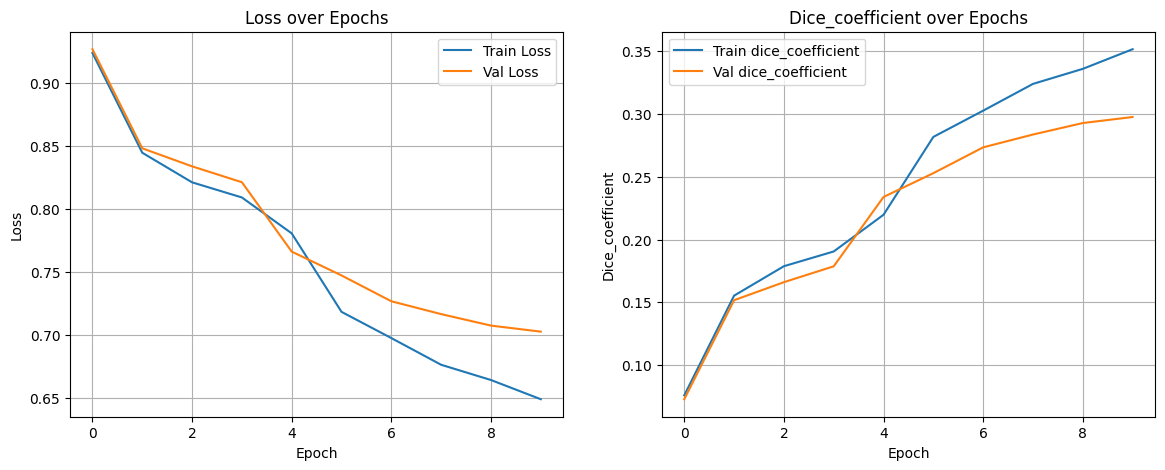

In [ ]:
def plot_history(history):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    metric_key = 'dice_coefficient' if 'dice_coefficient' in history.history else 'accuracy'
    plt.plot(history.history[metric_key], label=f'Train {metric_key}')
    if f'val_{metric_key}' in history.history:
        plt.plot(history.history[f'val_{metric_key}'], label=f'Val {metric_key}')
    plt.title(f'{metric_key.capitalize()} over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel(metric_key.capitalize())
    plt.legend()
    plt.grid(True)

    plt.show()

plot_history(model_history)

## Evaluasi Model

### Dice Ceofficient dan IoU

In [ ]:
# Proposed Architecture
test_loss, test_iou, test_dice = model.evaluate(test_ds)

60/60 ━━━━━━━━━━━━━━━━━━━━ 47s 724ms/step - dice_coefficient: 0.2764 - loss: 0.7236 - mean_iou: 0.1872


In [ ]:
# # U-Net
# test_loss, test_iou, test_dice = model.evaluate(test_generator)

### Recall and Specificity

#### 1 sub volume pada test generator

In [ ]:
for X_sub_volume, y_sub_volume in test_ds.take(1):
    X_sub_volume = X_sub_volume.numpy()
    y_sub_volume = y_sub_volume.numpy()
    break

print("Input shape:", X_sub_volume.shape)
print("Label shape:", y_sub_volume.shape)

Input shape: (2, 4, 160, 160, 16)
Label shape: (2, 3, 160, 160, 16)


In [ ]:
print(X_sub_volume.shape)

(2, 4, 160, 160, 16)


In [ ]:
satu_sub_volume_image = X_sub_volume[0]
print(satu_sub_volume_image.shape)

(4, 160, 160, 16)


In [ ]:
print(y_sub_volume.shape)

(2, 3, 160, 160, 16)


In [ ]:
satu_sub_volume_groundTruth = y_sub_volume[0]
print(satu_sub_volume_groundTruth.shape)

(3, 160, 160, 16)


In [ ]:
X_with_batch_dimension = np.expand_dims(satu_sub_volume_image, axis=0)
data_sen_spe = model.predict(X_with_batch_dimension)
threshold = 0.5
data_sen_spe[data_sen_spe > threshold] = 1.0
data_sen_spe[data_sen_spe <= threshold] = 0.0

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


In [ ]:
def visualize_patch(volume, mask, slice_idx=None):
    if volume.ndim == 4:
        volume = volume[0]

    if slice_idx is None:
        slice_idx = volume.shape[-1] // 2

    img_slice = volume[:, :, slice_idx]
    mask_slice = mask[:, :, slice_idx] if mask.ndim == 3 else mask

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_slice, cmap="gray")
    plt.title("MRI Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img_slice, cmap="gray")
    plt.imshow(mask_slice, cmap="jet", alpha=0.5)
    plt.title("Segmentation")
    plt.axis("off")

Sub Volume dan Mask (ground truth)


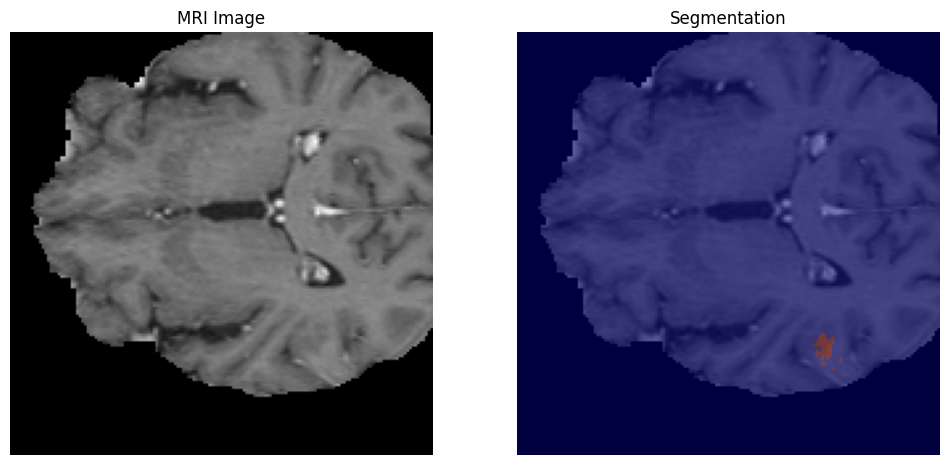

Sub Volume dan Mask (predicton)


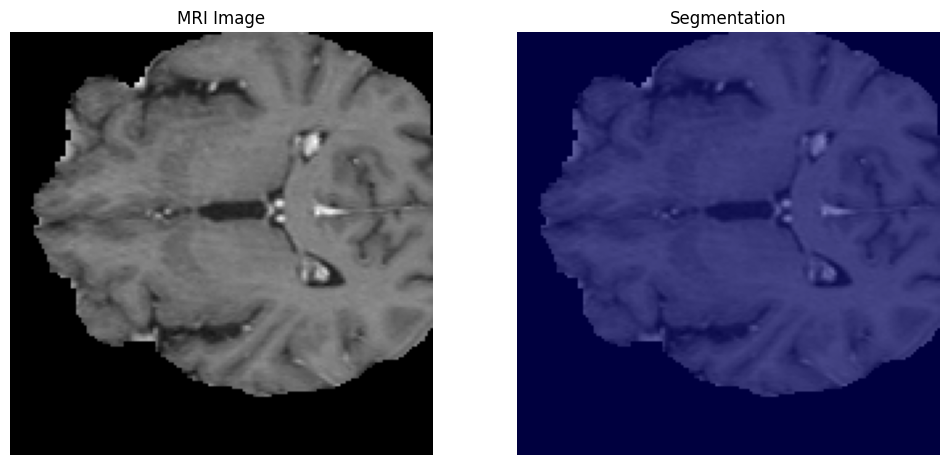

In [ ]:
print("Sub Volume dan Mask (ground truth)")
visualize_patch(satu_sub_volume_image[0, :, :, :], satu_sub_volume_groundTruth[0])
plt.show()
print("Sub Volume dan Mask (predicton)")
visualize_patch(satu_sub_volume_image[0, :, :, :], data_sen_spe[0, 0, :, :, :])
plt.show()

In [ ]:
def hitung_recall_specificity_satu_kelas(pred, label, class_num):
  class_pred = pred[class_num]
  class_label = label[class_num]
  tp = np.sum((class_pred==1) * (class_label==1))
  tn = np.sum((class_pred==0) * (class_label==0))
  fp = np.sum((class_pred==1) * (class_label==0))
  fn = np.sum((class_pred==0) * (class_label==1))
  if tp + fn == 0:
    recall = 0
  else:
      recall = tp / (tp + fn)

  if (tn + fp) == 0:
      specificity = 0
  else:
    specificity = tn / (tn + fp)
  return recall, specificity

def hitung_recall_specificity_setiap_kelas(pred, label):
  patches_matriks = pd.DataFrame(
      columns = ['Endema',
                 'Non-Enhancing Tumor',
                 'Enhancing Tumor'],
      index = ['Recall',
               'Specificity']
  )
  for i, class_name in enumerate(patches_matriks.columns):
    rec,spec = hitung_recall_specificity_satu_kelas(pred, label, i)
    patches_matriks.loc['Recall', class_name] = round(rec, 4)
    patches_matriks.loc['Specificity', class_name] = round(spec, 4)
  return patches_matriks

sens_spe = hitung_recall_specificity_setiap_kelas(data_sen_spe[0], satu_sub_volume_groundTruth)

print(sens_spe)

            Endema Non-Enhancing Tumor Enhancing Tumor
Recall         0.0                 0.0             0.0
Specificity    1.0                 1.0             1.0


#### semua sub volume pada test generator

In [ ]:
def hitung_recall_specificity_satu_kelas(pred, label, class_num):
  class_pred = pred[class_num]
  class_label = label[class_num]
  tp = np.sum((class_pred==1) * (class_label==1))
  tn = np.sum((class_pred==0) * (class_label==0))
  fp = np.sum((class_pred==1) * (class_label==0))
  fn = np.sum((class_pred==0) * (class_label==1))
  if tp + fn == 0:
    recall = 0
  else:
      recall = tp / (tp + fn)

  if (tn + fp) == 0:
      specificity = 0
  else:
    specificity = tn / (tn + fp)
  return recall, specificity

def hitung_recall_specificity_setiap_kelas(pred, label):
  patches_matriks = pd.DataFrame(
      columns = ['Endema',
                 'Non-Enhancing Tumor',
                 'Enhancing Tumor'],
      index = ['Recall',
               'Specificity']
  )
  for i, class_name in enumerate(patches_matriks.columns):
    rec,spec = hitung_recall_specificity_satu_kelas(pred, label, i)
    patches_matriks.loc['Recall', class_name] = round(rec, 4)
    patches_matriks.loc['Specificity', class_name] = round(spec, 4)
  return patches_matriks

In [ ]:
all_sens_spec = []

for i, (X_sub_volume, y_sub_volume) in enumerate(test_ds):
    X_sub_volume = X_sub_volume.numpy()
    y_sub_volume = y_sub_volume.numpy()

    for j in range(X_sub_volume.shape[0]):
        satu_sub_volume_image = X_sub_volume[j]
        satu_sub_volume_groundTruth = y_sub_volume[j]

        X_with_batch_dimension = np.expand_dims(satu_sub_volume_image, axis=0)
        data_sen_spe = model.predict(X_with_batch_dimension)

        threshold = 0.5
        data_sen_spe = (data_sen_spe > threshold).astype(np.float32)

        sens_spe = hitung_recall_specificity_setiap_kelas(
            data_sen_spe[0], satu_sub_volume_groundTruth
        )
        all_sens_spec.append(sens_spe)

result = pd.concat(all_sens_spec, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━

In [ ]:
result = pd.concat(all_sens_spec, axis=1)
result_df = pd.DataFrame(result.values.T, index=result.columns, columns=result.index)

print(result_df)

                     Recall Specificity
Endema                  0.0         1.0
Non-Enhancing Tumor     0.0         1.0
Enhancing Tumor         0.0         1.0
Endema               0.0902      0.9995
Non-Enhancing Tumor  0.6096      0.9954
...                     ...         ...
Non-Enhancing Tumor     0.0         1.0
Enhancing Tumor           0         1.0
Endema                    0         1.0
Non-Enhancing Tumor     0.0         1.0
Enhancing Tumor           0         1.0

[360 rows x 2 columns]


In [ ]:
result_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 360 entries, Endema to Enhancing Tumor
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Recall       360 non-null    object
 1   Specificity  360 non-null    object
dtypes: object(2)
memory usage: 8.4+ KB


In [ ]:
# RSU
result_df['Recall'] = result_df['Recall'].astype(float)
result_df['Specificity'] = result_df['Specificity'].astype(float)
averages = result_df.groupby(result_df.index).mean()
print(averages)

                       Recall  Specificity
Endema               0.319666     0.993797
Enhancing Tumor      0.387512     0.992783
Non-Enhancing Tumor  0.520218     0.978079


In [ ]:
#RSU
averages = result_df.groupby(result_df.index).mean()
recall_specificity_avg = averages.mean()
print(recall_specificity_avg)


Recall         0.409132
Specificity    0.988219
dtype: float64


In [ ]:
# # U-Net
# result_df['Recall'] = result_df['Recall'].astype(float)
# result_df['Specificity'] = result_df['Specificity'].astype(float)
# averages = result_df.groupby(result_df.index).mean()
# print(averages)


In [ ]:
# # U-Net
# averages = result_df.groupby(result_df.index).mean()
# recall_specificity_avg = averages.mean()
# print(recall_specificity_avg)

In [ ]:
# result = pd.concat(all_sens_spec, axis=1)
# result.columns = ['Endema', 'Non-Enhancing Tumor', 'Enhancing Tumor'] * (len(test_generator) * X_sub_volume.shape[0])
# average_per_class = result.groupby(level=0, axis=1).mean()
# average_per_class_fix = average_per_class.reindex(columns=['Endema', 'Non-Enhancing Tumor', 'Enhancing Tumor'])
# print(average_per_class_fix)